# UNet: noisy 21cm → v_z (GRIZZLY)

Basic 3D UNet that learns to map a noisy 21cm brightness-temperature cube to the
underlying line-of-sight peculiar-velocity field, using GRIZZLY snapshots.

Only one simulation volume is available, so different redshifts act as different
training scenes. Patches of size 64³ are used to have many training examples.

Steps:
1. Load N GRIZZLY snapshots (density, xHI, v_z) and build T_b.
2. Add realistic HERA thermal noise to each T_b cube via `tuesday.core.observe_coeval`
   (same pipeline as notebook `04`); normalize inputs and targets.
3. Split volumes into 64³ non-overlapping patches → 64% train / 16% val / 20% test
   (pooled across redshifts).
4. Define a 3D UNet (JAX / Flax) adapted from the reference implementation.
5. Train with Adam on MSE in normalized v_z.
6. Evaluate on the held-out test set: slice visualization + per-patch R².

> **Dependencies** (not in `pyproject.toml` yet):
> ```bash
> uv pip install jax flax optax
> ```
> CPU is fine for this demo (slow). For GPU, install `jax[cuda12]`.

In [1]:
%load_ext autoreload
%autoreload 2
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent))

import numpy as np
import matplotlib.pyplot as plt
from astropy import units as un

import jax
import jax.numpy as jnp
from flax import linen as nn
import optax

from tuesday.core import observe_coeval

from src import grizzly as gz
from src.noise_filters import build_hera_observation

plt.rcParams.update({'figure.dpi': 110, 'font.size': 10})
print('JAX devices:', jax.devices())

JAX devices: [CpuDevice(id=0)]


## 1. Config

In [2]:
DATA_DIR = '../data_grizzly/'

N_SNAPSHOTS = 8        # number of GRIZZLY redshifts to use
PATCH = 64             # patch side
CROP = 512             # cube side we actually use (multiple of PATCH, ≤ 540)
assert CROP % PATCH == 0

# Train/val/test split (patch-level, pooled across redshifts)
TEST_FRAC = 0.20
VAL_FRAC  = 0.20      # fraction of the non-test (80%) pool → overall 16%

# HERA observation for thermal-noise generation (same as notebook 04 reference)
HERA_KW = dict(
    hex_num=11, split_core=True, outriggers=2, dish_size_m=14.0,
    track_hours=6.0, time_per_day_hours=6.0, n_days=180,
)

BATCH_SIZE = 4
EPOCHS = 5
LR = 1e-3

N_BASE_FILTERS = 6
DEPTH = 3              # scaled down from the 5-level reference

SEED = 0
rng_np = np.random.default_rng(SEED)

## 2. Load GRIZZLY snapshots → (T_b, v_z)

For each redshift load (density, xHI, v_z), build T_b, keep only `(T_b, v_z)` cropped
to `CROP³`. v_z is stored in km/s so training values are order-unity after scaling.

In [3]:
zs_all = gz.available_redshifts(DATA_DIR)
# Pick N_SNAPSHOTS evenly spaced redshifts through the EoR
idx = np.linspace(0, len(zs_all) - 1, N_SNAPSHOTS).astype(int)
zs = zs_all[idx]
print(f'Using {len(zs)} redshifts: {np.round(zs, 3)}')

tb_list, vz_list = [], []
for z in zs:
    den, xhi, vz = gz.load_snapshot(DATA_DIR, z, crop=True)  # 540^3 each
    tb = gz.brightness_temp(den, xhi, z)                      # mK
    # crop central CROP^3
    s = (540 - CROP) // 2
    tb = tb[s:s+CROP, s:s+CROP, s:s+CROP]
    vz = vz[s:s+CROP, s:s+CROP, s:s+CROP] * 1e-5              # cm/s → km/s
    tb_list.append(tb.astype(np.float32))
    vz_list.append(vz.astype(np.float32))
    print(f'  z={z:.3f}  <xHI>={xhi.mean():.3f}  '
          f'T_b[mK]=({tb.mean():+.2f}±{tb.std():.2f})  '
          f'v_z[km/s]=({vz.mean():+.1f}±{vz.std():.1f})')
    del den, xhi

Using 8 redshifts: [ 6.056  6.483  6.981  7.57   8.283  9.164 10.29  12.048]
  z=6.056  <xHI>=0.000  T_b[mK]=(+0.00±0.00)  v_z[km/s]=(+5.6±157.3)
  z=6.483  <xHI>=0.288  T_b[mK]=(+5.40±9.29)  v_z[km/s]=(+5.4±152.8)
  z=6.981  <xHI>=0.526  T_b[mK]=(+11.09±11.97)  v_z[km/s]=(+5.3±148.0)
  z=7.570  <xHI>=0.703  T_b[mK]=(+16.36±12.88)  v_z[km/s]=(+5.1±142.9)
  z=8.283  <xHI>=0.829  T_b[mK]=(+21.00±12.77)  v_z[km/s]=(+4.9±137.4)
  z=9.164  <xHI>=0.916  T_b[mK]=(+24.92±12.01)  v_z[km/s]=(+4.7±131.3)
  z=10.290  <xHI>=0.967  T_b[mK]=(+28.12±10.98)  v_z[km/s]=(+4.4±124.6)
  z=12.048  <xHI>=0.994  T_b[mK]=(+31.26±9.81)  v_z[km/s]=(+4.1±115.9)


## 3. Add realistic thermal noise + normalize

For each snapshot, run `observe_coeval` on the clean T_b cube with the HERA-350
reference observation (same settings notebook `04` uses for its empirical noise).
This returns a realistic noisy cube: signal + thermal noise at the per-UV-cell RMS
set by the array, `T_sys`, integration time, and primary beam.

We use `remove_wedge=False, remove_mean=False, multiply_by_beam=False` so the output
is `T_b + n_thermal` with no wedge filter applied — keeps the mapping target clean.

Each cube is then standardized per snapshot (EoR state changes a lot with z).

In [4]:
# Build the HERA observation once (antenna positions are redshift-independent)
_, obs_hera, _ = build_hera_observation(**HERA_KW)
print(f'HERA-350 ref: {obs_hera.n_days} d × {obs_hera.time_per_day}')

# Run observe_coeval per snapshot to get signal + thermal noise
box_len_mpc = gz.BOX_CROP_MPC * CROP / gz.N_CROP   # matches the cropped cube

tb_noisy_list = []
for i, (tb, z) in enumerate(zip(tb_list, zs)):
    realizations = observe_coeval(
        box=tb * un.mK,
        box_length=box_len_mpc * un.Mpc,
        observation=obs_hera,
        redshift=float(z),
        nrealizations=1,
        remove_wedge=False, remove_mean=False, multiply_by_beam=False,
        seed=SEED + i,
    )
    tb_noisy = realizations[0].to(un.mK).value.astype(np.float32)
    # observe_coeval can leave inf/nan in unmeasured UV cells → zero them
    n_bad = int((~np.isfinite(tb_noisy)).sum())
    tb_noisy = np.nan_to_num(tb_noisy, nan=0.0, posinf=0.0, neginf=0.0)
    assert np.isfinite(tb_noisy).all()
    tb_noisy_list.append(tb_noisy)
    print(f'  z={z:.3f}  noisy std={tb_noisy.std():.2f} mK  '
          f'(clean std={tb.std():.2f} mK)  fixed {n_bad} non-finite cells')

# Normalize: noisy cube → standardize by its OWN mean/std (noise dominates, so
# clean-T_b stats would leave inputs at O(100+) and blow up BatchNorm training).
# v_z is standardized per snapshot by its own mean/std.
vz_means = np.array([x.mean() for x in vz_list], dtype=np.float32)
vz_stds  = np.array([x.std()  for x in vz_list], dtype=np.float32)

x_list, y_list = [], []
for i in range(N_SNAPSHOTS):
    tb_n = tb_noisy_list[i]
    x_list.append(((tb_n - tb_n.mean()) / tb_n.std()).astype(np.float32))
    y_list.append(((vz_list[i] - vz_means[i]) / vz_stds[i]).astype(np.float32))
    assert np.isfinite(x_list[i]).all() and np.isfinite(y_list[i]).all()

# Free the big clean cubes
del tb_list, vz_list, tb_noisy_list
print(f'x shape per snapshot: {x_list[0].shape}')

HERA-350 ref: 180 d × 6.0 h


finding redundancies: 61075ants [00:00, 1661039.14ants/s]


  z=6.056  noisy std=225.61 mK  (clean std=0.00 mK)  fixed 0 non-finite cells
  z=6.483  noisy std=271.07 mK  (clean std=9.29 mK)  fixed 0 non-finite cells
  z=6.981  noisy std=327.87 mK  (clean std=11.97 mK)  fixed 0 non-finite cells
  z=7.570  noisy std=438.62 mK  (clean std=12.88 mK)  fixed 0 non-finite cells
  z=8.283  noisy std=543.84 mK  (clean std=12.77 mK)  fixed 0 non-finite cells
  z=9.164  noisy std=594.94 mK  (clean std=12.01 mK)  fixed 0 non-finite cells
  z=10.290  noisy std=851.23 mK  (clean std=10.98 mK)  fixed 0 non-finite cells
  z=12.048  noisy std=1454.51 mK  (clean std=9.81 mK)  fixed 0 non-finite cells
x shape per snapshot: (512, 512, 512)


## 4. Patch extraction + train / val / test split

Non-overlapping `PATCH³` tiles from every snapshot are pooled together and
shuffled, then split 64 % train / 16 % val / 20 % test.

In [5]:
def tile(cube, patch):
    n = cube.shape[0] // patch
    return (cube
            .reshape(n, patch, n, patch, n, patch)
            .transpose(0, 2, 4, 1, 3, 5)
            .reshape(-1, patch, patch, patch))

X_all = np.concatenate([tile(x_list[i], PATCH) for i in range(N_SNAPSHOTS)])[..., None]
Y_all = np.concatenate([tile(y_list[i], PATCH) for i in range(N_SNAPSHOTS)])[..., None]
n_total = X_all.shape[0]

# Shuffle and split: 20% test, then 20% of the rest as val → 64/16/20
order = rng_np.permutation(n_total)
n_test  = int(round(TEST_FRAC * n_total))
n_rest  = n_total - n_test
n_val   = int(round(VAL_FRAC * n_rest))
n_train = n_rest - n_val

test_idx  = order[:n_test]
val_idx   = order[n_test:n_test + n_val]
train_idx = order[n_test + n_val:]

X_train, Y_train = X_all[train_idx], Y_all[train_idx]
X_val,   Y_val   = X_all[val_idx],   Y_all[val_idx]
X_test,  Y_test  = X_all[test_idx],  Y_all[test_idx]

del X_all, Y_all
print(f'Total patches: {n_total}')
print(f'  train: {X_train.shape[0]}  ({X_train.shape[0]/n_total:.0%})')
print(f'  val:   {X_val.shape[0]}    ({X_val.shape[0]/n_total:.0%})')
print(f'  test:  {X_test.shape[0]}   ({X_test.shape[0]/n_total:.0%})')

Total patches: 4096
  train: 2622  (64%)
  val:   655    (16%)
  test:  819   (20%)


## 5. UNet (adapted from the reference JAX implementation)

Same structure as the provided UNet (periodic padding, batchnorm + leaky ReLU,
context+localization modules), but scaled down (`DEPTH=3`, `N_BASE_FILTERS=16`).
The `DisplacementTensors` preprocessing from the original is omitted here — that
block interprets the input as a density field, which doesn't match a noisy T_b cube.

In [6]:
class PeriodicPad(nn.Module):
    @nn.compact
    def __call__(self, x):
        return jnp.pad(x, ((0, 0), (1, 1), (1, 1), (1, 1), (0, 0)), mode='wrap')

class SpatialDropout3D(nn.Module):
    rate: float
    @nn.compact
    def __call__(self, x, deterministic=False):
        if deterministic or self.rate == 0:
            return x
        keep = 1.0 - self.rate
        mask = jax.random.bernoulli(self.make_rng('dropout'), keep,
                                     (x.shape[0], x.shape[-1]))
        return x * mask[:, None, None, None, :] / keep

class UpSample3D(nn.Module):
    size: tuple = (2, 2, 2)
    @nn.compact
    def __call__(self, x):
        b, d1, d2, d3, c = x.shape
        return jax.image.resize(x, (b, d1*self.size[0], d2*self.size[1],
                                    d3*self.size[2], c), method='nearest')

def conv_block(x, features, training, kernel=(3,3,3), strides=(1,1,1)):
    x = nn.Conv(features, kernel_size=kernel, strides=strides, padding='VALID')(x)
    x = nn.BatchNorm(use_running_average=not training)(x)
    return nn.leaky_relu(x)

def context_module(x, features, training, dropout_rate):
    x = conv_block(PeriodicPad()(x), features, training)
    x = SpatialDropout3D(dropout_rate)(x, deterministic=not training)
    x = conv_block(PeriodicPad()(x), features, training)
    return x

def localization_module(x, features, training):
    x = conv_block(PeriodicPad()(x), features, training)
    x = conv_block(x, features, training, kernel=(1,1,1))
    return x

def upsampling_module(x, features, training):
    x = UpSample3D()(x)
    return conv_block(PeriodicPad()(x), features, training)

class UNet3D(nn.Module):
    n_base: int = N_BASE_FILTERS
    depth: int = DEPTH
    dropout_rate: float = 0.3

    @nn.compact
    def __call__(self, x, training=True):
        skips, level_filters = [], []
        for lvl in range(self.depth):
            f = (2 ** lvl) * self.n_base
            level_filters.append(f)
            if lvl == 0:
                x = conv_block(PeriodicPad()(x), f, training)
            else:
                x = conv_block(PeriodicPad()(x), f, training, strides=(2,2,2))
            prev = x
            x = context_module(x, f, training, self.dropout_rate)
            x = prev + x
            skips.append(x)

        for lvl in range(self.depth - 2, -1, -1):
            x = upsampling_module(x, level_filters[lvl], training)
            x = jnp.concatenate([skips[lvl], x], axis=-1)
            x = localization_module(x, level_filters[lvl], training)

        return nn.Conv(1, kernel_size=(1,1,1))(x)

## 6. Initialize and train

In [7]:
model = UNet3D()
key = jax.random.PRNGKey(SEED)
dummy = jnp.zeros((1, PATCH, PATCH, PATCH, 1), dtype=jnp.float32)
variables = model.init(
    {'params': key, 'dropout': jax.random.PRNGKey(SEED + 1)},
    dummy, training=True,
)
params = variables['params']
batch_stats = variables['batch_stats']

n_params = sum(p.size for p in jax.tree_util.tree_leaves(params))
print(f'UNet params: {n_params:,}')

optimizer = optax.adam(LR)
opt_state = optimizer.init(params)

UNet params: 70,873


In [8]:
@jax.jit
def train_step(params, batch_stats, opt_state, x, y, dropout_key):
    def loss_fn(p):
        out, new_state = model.apply(
            {'params': p, 'batch_stats': batch_stats},
            x, training=True, mutable=['batch_stats'],
            rngs={'dropout': dropout_key},
        )
        loss = jnp.mean((out - y) ** 2)
        return loss, new_state['batch_stats']
    (loss, new_batch_stats), grads = jax.value_and_grad(loss_fn, has_aux=True)(params)
    updates, opt_state = optimizer.update(grads, opt_state, params)
    params = optax.apply_updates(params, updates)
    return params, new_batch_stats, opt_state, loss

@jax.jit
def eval_step(params, batch_stats, x, y):
    out = model.apply({'params': params, 'batch_stats': batch_stats},
                      x, training=False, mutable=False)
    return jnp.mean((out - y) ** 2), out

In [9]:
def iterate_batches(X, Y, batch_size, rng):
    n = X.shape[0]
    order = rng.permutation(n)
    for i in range(0, n - batch_size + 1, batch_size):
        idx = order[i:i+batch_size]
        yield jnp.asarray(X[idx]), jnp.asarray(Y[idx])

drop_key = jax.random.PRNGKey(SEED + 2)
history = {'train': [], 'val': []}

for epoch in range(EPOCHS):
    train_losses = []
    for x, y in iterate_batches(X_train, Y_train, BATCH_SIZE, rng_np):
        drop_key, sub = jax.random.split(drop_key)
        params, batch_stats, opt_state, loss = train_step(
            params, batch_stats, opt_state, x, y, sub,
        )
        train_losses.append(float(loss))

    val_losses = []
    for x, y in iterate_batches(X_val, Y_val, BATCH_SIZE, rng_np):
        vloss, _ = eval_step(params, batch_stats, x, y)
        val_losses.append(float(vloss))

    history['train'].append(np.mean(train_losses))
    history['val'].append(np.mean(val_losses))
    print(f'epoch {epoch+1:2d}/{EPOCHS}  '
          f'train MSE={history["train"][-1]:.4f}  '
          f'val MSE={history["val"][-1]:.4f}')

epoch  1/5  train MSE=1.0222  val MSE=0.9720
epoch  2/5  train MSE=1.0068  val MSE=0.9724
epoch  3/5  train MSE=1.0064  val MSE=0.9696
epoch  4/5  train MSE=1.0061  val MSE=0.9716
epoch  5/5  train MSE=1.0061  val MSE=0.9705


## 7. Evaluation (test set)

Training curve uses train/val. Final R² and slice visualization are computed on
the held-out 20 % test patches — these were never seen during training or used
for early-stopping-style decisions.

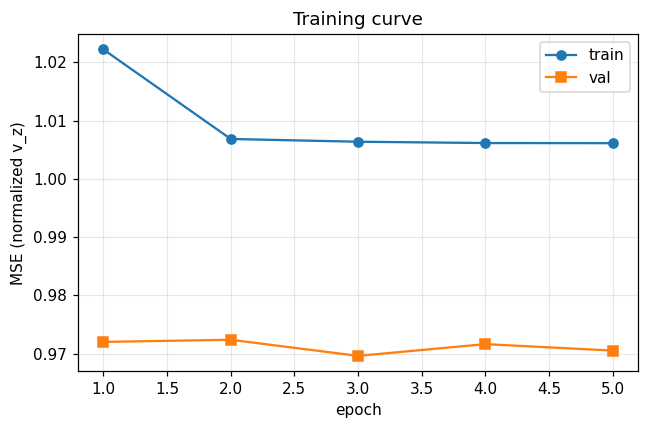

In [10]:
fig, ax = plt.subplots(figsize=(6, 4))
ep = np.arange(1, EPOCHS + 1)
ax.plot(ep, history['train'], 'o-', label='train')
ax.plot(ep, history['val'],   's-', label='val')
ax.set_xlabel('epoch'); ax.set_ylabel('MSE (normalized v_z)')
ax.set_title('Training curve'); ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

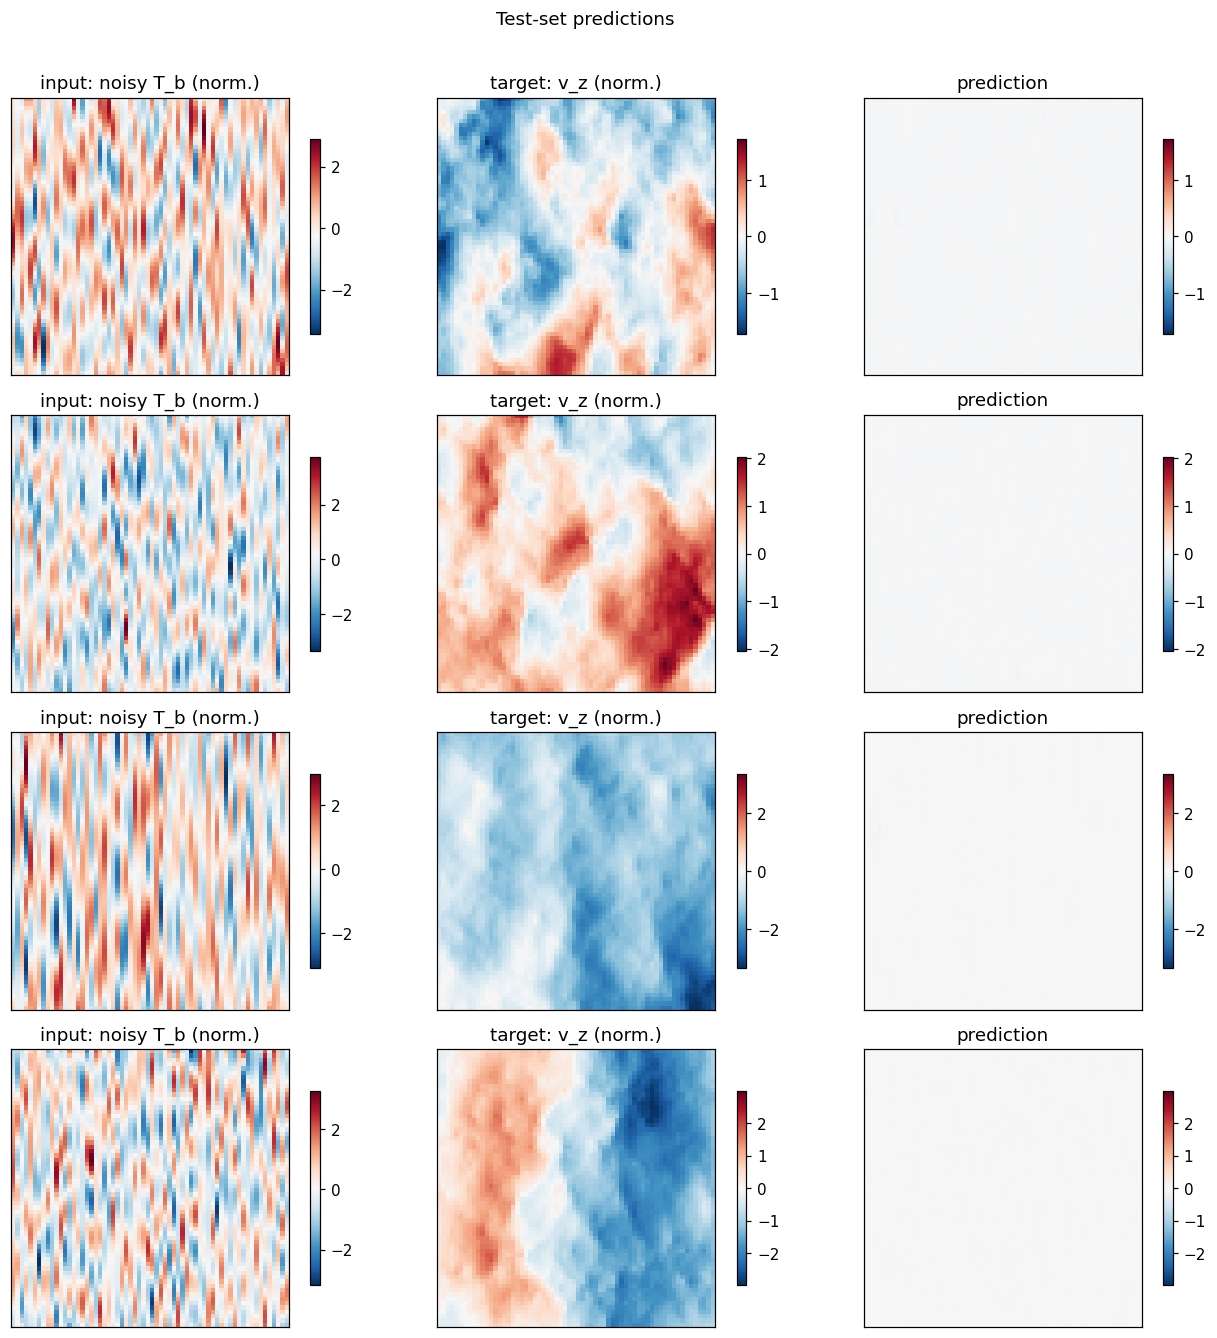

In [11]:
# Predict on a few test patches and show a mid-slice
n_show = min(4, X_test.shape[0])
x_show = jnp.asarray(X_test[:n_show])
y_show = Y_test[:n_show, ..., 0]
_, pred = eval_step(params, batch_stats, x_show, jnp.asarray(Y_test[:n_show]))
pred = np.asarray(pred)[..., 0]

mid = PATCH // 2
fig, axes = plt.subplots(n_show, 3, figsize=(12, 3 * n_show))
if n_show == 1:
    axes = axes[None, :]
for r in range(n_show):
    vmax_y = float(np.max(np.abs(y_show[r, mid])))
    im0 = axes[r, 0].imshow(np.asarray(x_show)[r, mid, ..., 0], cmap='RdBu_r')
    axes[r, 0].set_title('input: noisy T_b (norm.)')
    plt.colorbar(im0, ax=axes[r, 0], shrink=0.7)
    im1 = axes[r, 1].imshow(y_show[r, mid], cmap='RdBu_r', vmin=-vmax_y, vmax=vmax_y)
    axes[r, 1].set_title('target: v_z (norm.)')
    plt.colorbar(im1, ax=axes[r, 1], shrink=0.7)
    im2 = axes[r, 2].imshow(pred[r, mid], cmap='RdBu_r', vmin=-vmax_y, vmax=vmax_y)
    axes[r, 2].set_title('prediction')
    plt.colorbar(im2, ax=axes[r, 2], shrink=0.7)
    for a in axes[r]:
        a.set_xticks([]); a.set_yticks([])
plt.suptitle('Test-set predictions', y=1.01)
plt.tight_layout(); plt.show()

Test R² — mean=-0.996, median=-0.490, min=-6.491, max=-0.000


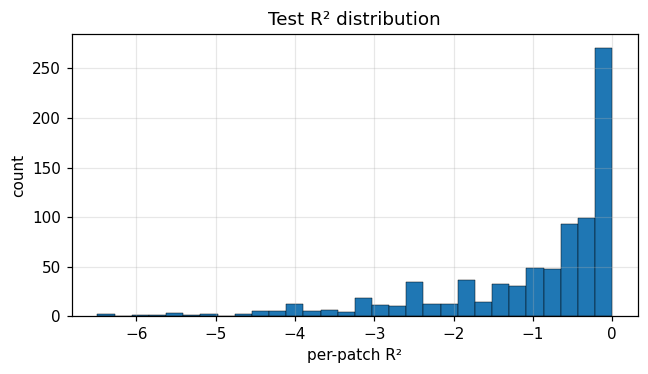

In [12]:
# Per-patch R² on the full test set
r2s = []
for i in range(0, X_test.shape[0], BATCH_SIZE):
    xb = jnp.asarray(X_test[i:i+BATCH_SIZE])
    yb = Y_test[i:i+BATCH_SIZE, ..., 0]
    _, pb = eval_step(params, batch_stats, xb, jnp.asarray(Y_test[i:i+BATCH_SIZE]))
    pb = np.asarray(pb)[..., 0]
    for j in range(pb.shape[0]):
        ss_res = np.sum((yb[j] - pb[j]) ** 2)
        ss_tot = np.sum((yb[j] - yb[j].mean()) ** 2)
        r2s.append(1.0 - ss_res / max(ss_tot, 1e-12))
r2s = np.array(r2s)
print(f'Test R² — mean={r2s.mean():+.3f}, median={np.median(r2s):+.3f}, '
      f'min={r2s.min():+.3f}, max={r2s.max():+.3f}')
plt.figure(figsize=(6, 3.5))
plt.hist(r2s, bins=30, color='C0', edgecolor='k', lw=0.3)
plt.xlabel('per-patch R²'); plt.ylabel('count'); plt.title('Test R² distribution')
plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

## Notes / next steps

- Only one simulation volume → train and test patches are spatially disjoint but
  share the same realization of the IGM. Cosmic-variance generalization is
  untested.
- Noise here is HERA thermal noise via `observe_coeval` (same pipeline as notebook
  `04`). To also apply wedge filtering, pass `remove_wedge=True, wedge_slope=1.0`
  when generating the noisy cubes — that becomes a much harder task.
- Swap the array configuration in `HERA_KW` (e.g. `n_days=720, time_per_day_hours=1.0`)
  to train against the short-track observing strategy.
- For a stronger model, bring back the full depth=5 UNet and add the
  `DisplacementTensors` branch — but only makes physical sense if the input
  is a density-like field.